# Evolutionary Algorithm for the 0/1 Knapsack Problem

In this notebook I use the Knapsack Problem.
It has a natural constraint: the backpack cannot exceed a maximum capacity.

I use a repair-based direct approach: after crossover and mutation, I repair any infeasible solution so that it becomes feasible again.

Each item has:

- a **value**: how important the item is;
- a **weight**: how heavy the item is.

The goal is to select items with the largest total value, but without exceeding the backpack capacity.


## 1. Problem definition

For each item $i$, we know:

- $v_i$: value of item $i$;
- $w_i$: weight of item $i$;
- $x_i \in \{0,1\}$: decision variable.

The meaning of $x_i$ is:

$$
x_i =
\begin{cases}
1 & \text{if item } i \text{ is selected} \\
0 & \text{if item } i \text{ is not selected}
\end{cases}
$$

The objective is to maximize total value:

$$
\max f(x) = \sum_{i=1}^{n} x_i v_i
$$

subject to the capacity constraint:

$$
\sum_{i=1}^{n} x_i w_i \leq C
$$

where $C$ is the maximum capacity of the knapsack.


## 2. Evolutionary Algorithm design

### Representation
Each individual is a binary vector:

$$x = [x_1, x_2, ..., x_n]$$

Example: $[1,0,1,0,1]$ means: select items 1, 3, and 5.

### Fitness function
Because I use repair, every final evaluated individual is feasible. Therefore, the fitness is simply:

$$fitness(x) = \sum_{i=1}^{n} x_i v_i$$

Higher fitness is better.

### Constraint handling: repair function
If an individual is overweight, I remove items until the constraint is satisfied.

The repair rule removes items with the worst value-to-weight ratio first:

$$ratio_i = \frac{v_i}{w_i}$$

This means I first remove items that give little value for their weight.

### Parent selection
I use binary tournament selection:

1. Randomly choose 2 individuals.
2. Select the one with higher fitness.

### Crossover
I use one-point crossover with probability $p_c = 0.8$.

### Mutation
I use bit-flip mutation with probability:

$$p_m = \frac{1}{n}$$

where $n$ is the number of items.

### Survivor selection
I use elitism.


## 3. Pseudocode

```text
Input:
    values, weights, capacity
    population_size
    max_evaluations
    crossover_probability
    mutation_probability

Create an initial random population
Repair each individual if it violates the capacity constraint
Evaluate each individual

while number_of_evaluations < max_evaluations:

    Save the best individual as elite
    Create an empty offspring population

    while offspring population is not full:

        parent1 = tournament_selection(population)
        parent2 = tournament_selection(population)

        with probability crossover_probability:
            child1, child2 = one_point_crossover(parent1, parent2)
        otherwise:
            child1 = copy(parent1)
            child2 = copy(parent2)

        child1 = bit_flip_mutation(child1)
        child2 = bit_flip_mutation(child2)

        child1 = repair(child1)
        child2 = repair(child2)

        evaluate child1 and child2
        add children to offspring population

    Replace the worst offspring with the elite individual
    population = offspring population

Return the best individual found
```


## 4. Why these choices?

1.- Knapsack Problem because it is a combinatorial optimization problem with a clear constraint.

2.- Binary representation because each item has only two possible states: selected or not selected.

3.- A repair function because it is easy to understand and keeps the search focused on feasible solutions.

4.- Tournament selection because it is simple and does not require fitness scaling.

5.- One-point crossover because it is a standard operator for binary strings.

6.- Bit-flip mutation because it is the natural mutation operator for binary vectors.

7.- Elitism because it protects the best solution found so far.


## 5. Python implementation

In [1]:
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def total_weight(individual, weights):
    # float preserves the decimal benchmark instance (f5).
    return float(np.sum(individual * weights))


def total_value(individual, values):
    return float(np.sum(individual * values))


def repair(individual, values, weights, capacity):
    # Remove selected items with the worst value/weight ratio until feasible.
    individual = individual.copy()
    while total_weight(individual, weights) > capacity + 1e-12:
        selected_items = np.where(individual == 1)[0]
        ratios = values[selected_items] / weights[selected_items]
        item_to_remove = selected_items[np.argmin(ratios)]
        individual[item_to_remove] = 0
    return individual


def fitness(individual, values, weights, capacity):
    if total_weight(individual, weights) <= capacity + 1e-12:
        return total_value(individual, values)
    return 0.0


In [3]:
def create_individual(n_items, values, weights, capacity):
    # Create one random individual and repair it if necessary.
    individual = np.random.randint(0, 2, size=n_items)
    individual = repair(individual, values, weights, capacity)
    return individual


def initialize_population(population_size, n_items, values, weights, capacity):
    # Create the first population.
    population = []
    for _ in range(population_size):
        individual = create_individual(n_items, values, weights, capacity)
        population.append(individual)
    return np.array(population)

In [4]:
def tournament_selection(population, fitness_values, tournament_size=2):
    # Select one parent using tournament selection.
    candidate_indices = np.random.choice(len(population), size=tournament_size, replace=False)
    best_index = candidate_indices[np.argmax(fitness_values[candidate_indices])]
    return population[best_index].copy()


def one_point_crossover(parent1, parent2, crossover_probability):
    # Apply one-point crossover to two parents.
    n_items = len(parent1)
    if random.random() < crossover_probability:
        cut = random.randint(1, n_items - 1)
        child1 = np.concatenate([parent1[:cut], parent2[cut:]])
        child2 = np.concatenate([parent2[:cut], parent1[cut:]])
    else:
        child1 = parent1.copy()
        child2 = parent2.copy()
    return child1, child2


def bit_flip_mutation(individual, mutation_probability):
    # Flip each bit with probability mutation_probability.
    individual = individual.copy()
    for i in range(len(individual)):
        if random.random() < mutation_probability:
            individual[i] = 1 - individual[i]
    return individual

In [5]:
def evolutionary_algorithm_knapsack(
    values,
    weights,
    capacity,
    population_size=100,
    max_evaluations=5000,
    crossover_probability=0.8,
    random_seed=None
):
    # Evolutionary Algorithm for the Knapsack Problem.
    # The stop condition is a fixed number of fitness evaluations.
    if random_seed is not None:
        random.seed(random_seed)
        np.random.seed(random_seed)

    start_time = time.time()
    n_items = len(values)
    mutation_probability = 1 / n_items

    population = initialize_population(population_size, n_items, values, weights, capacity)
    fitness_values = np.array([fitness(ind, values, weights, capacity) for ind in population])
    evaluations = population_size

    best_history = [np.max(fitness_values)]
    avg_history = [np.mean(fitness_values)]

    while evaluations < max_evaluations:
        elite_index = np.argmax(fitness_values)
        elite = population[elite_index].copy()
        elite_fitness = fitness_values[elite_index]

        offspring = []
        offspring_fitness = []

        while len(offspring) < population_size and evaluations < max_evaluations:
            parent1 = tournament_selection(population, fitness_values)
            parent2 = tournament_selection(population, fitness_values)

            child1, child2 = one_point_crossover(parent1, parent2, crossover_probability)
            child1 = bit_flip_mutation(child1, mutation_probability)
            child2 = bit_flip_mutation(child2, mutation_probability)
            child1 = repair(child1, values, weights, capacity)
            child2 = repair(child2, values, weights, capacity)

            for child in [child1, child2]:
                if len(offspring) < population_size and evaluations < max_evaluations:
                    offspring.append(child)
                    offspring_fitness.append(fitness(child, values, weights, capacity))
                    evaluations += 1

        population = np.array(offspring)
        fitness_values = np.array(offspring_fitness)

        # Elitism: keep the previous best individual.
        worst_index = np.argmin(fitness_values)
        population[worst_index] = elite
        fitness_values[worst_index] = elite_fitness

        best_history.append(np.max(fitness_values))
        avg_history.append(np.mean(fitness_values))

    best_index = np.argmax(fitness_values)
    best_individual = population[best_index]

    return {
        "best_individual": best_individual,
        "best_fitness": fitness_values[best_index],
        "best_weight": total_weight(best_individual, weights),
        "elapsed_time": time.time() - start_time,
        "best_history": best_history,
        "avg_history": avg_history
    }

## 6. Kaggle benchmark

The ten low-dimensional 0/1 knapsack instances from the Kaggle dataset:

<https://www.kaggle.com/datasets/sc0v1n0/dataset-low-dimensional-01-knapsack-problems>

Each CSV stores the number of items and capacity in its first data row; the
remaining rows contain `(value, weight)` pairs. 

The published optimum is used only for evaluation, not by the evolutionary
algorithm.


In [6]:
from pathlib import Path
import io
import urllib.request
import zipfile

DATASET_URL = "https://www.kaggle.com/api/v1/datasets/download/sc0v1n0/dataset-low-dimensional-01-knapsack-problems"
DATA_DIR = Path("low_dimensional")

if not DATA_DIR.exists():
    print("Dataset folder not found; downloading the public Kaggle archive...")
    with urllib.request.urlopen(DATASET_URL) as response:
        archive = zipfile.ZipFile(io.BytesIO(response.read()))
        archive.extractall(".")

KNOWN_OPTIMA = {
    "f1_l_d_kp_10_269": 295.0,
    "f2_l_d_kp_20_878": 1024.0,
    "f3_l_d_kp_4_20": 35.0,
    "f4_l_d_kp_4_11": 23.0,
    "f5_l_d_kp_15_375": 481.0694,
    "f6_l_d_kp_10_60": 52.0,
    "f7_l_d_kp_7_50": 107.0,
    "f8_l_d_kp_23_10000": 9767.0,
    "f9_l0_d_kp_5_80": 130.0,  # Kaggle filename contains "l0".
    "f10_l_d_kp_20_879": 1025.0,
}


def load_kaggle_instance(path):
    raw = pd.read_csv(path)
    n_items = int(raw.iloc[0]["value"])
    capacity = float(raw.iloc[0]["weight"])
    items = raw.iloc[1:].reset_index(drop=True)
    if len(items) != n_items:
        raise ValueError(f"{path.name}: expected {n_items} items, found {len(items)}")
    values = items["value"].to_numpy(dtype=float)
    weights = items["weight"].to_numpy(dtype=float)
    return values, weights, capacity


instances = {}
for path in sorted(DATA_DIR.glob("*.csv")):
    key = path.stem
    values, weights, capacity = load_kaggle_instance(path)
    instances[key] = (values, weights, capacity, KNOWN_OPTIMA[key])

instance_overview = pd.DataFrame([
    {
        "instance": name,
        "items": len(values),
        "capacity": capacity,
        "known_optimum": optimum,
    }
    for name, (values, weights, capacity, optimum) in instances.items()
])

assert len(instances) == 10, f"Expected 10 instances, found {len(instances)}"
instance_overview


,instance,items,capacity,known_optimum
0,f10_l_d_kp_20_879,20,879.0,1025.0000
1,f1_l_d_kp_10_269,10,269.0,295.0000
2,f2_l_d_kp_20_878,20,878.0,1024.0000
3,f3_l_d_kp_4_20,4,20.0,35.0000
4,f4_l_d_kp_4_11,4,11.0,23.0000
5,f5_l_d_kp_15_375,15,375.0,481.0694
6,f6_l_d_kp_10_60,10,60.0,52.0000
7,f7_l_d_kp_7_50,7,50.0,107.0000
8,f8_l_d_kp_23_10000,23,10000.0,9767.0000
9,f9_l0_d_kp_5_80,5,80.0,130.0000


## 7. Experimental setup

The same configuration is used for all ten instances. Each instance is run
10 times with fixed, distinct seeds. Besides execution time, the analysis
reports the absolute/relative gap to the known optimum and whether each run
reached that optimum (using a small tolerance for decimal data).

| Parameter | Value |
|---|---:|
| Population size | 100 |
| Maximum evaluations | 5,000 |
| Crossover probability | 0.8 |
| Mutation probability | $1/n$ |
| Runs per instance | 10 |


In [7]:
POPULATION_SIZE = 100
MAX_EVALUATIONS = 5000
CROSSOVER_PROBABILITY = 0.8
RUNS = 10
OPTIMUM_TOLERANCE = 1e-3

all_results = []
histories = {}

for instance_name, (values, weights, capacity, known_optimum) in instances.items():
    histories[instance_name] = []
    for run in range(RUNS):
        result = evolutionary_algorithm_knapsack(
            values=values,
            weights=weights,
            capacity=capacity,
            population_size=POPULATION_SIZE,
            max_evaluations=MAX_EVALUATIONS,
            crossover_probability=CROSSOVER_PROBABILITY,
            random_seed=1000 + run,
        )
        gap = max(0.0, known_optimum - result["best_fitness"])
        all_results.append({
            "instance": instance_name,
            "run": run + 1,
            "best_fitness": result["best_fitness"],
            "final_average_population_fitness": result["avg_history"][-1],
            "known_optimum": known_optimum,
            "absolute_gap": gap,
            "relative_gap_percent": 100 * gap / known_optimum,
            "reached_optimum": gap <= OPTIMUM_TOLERANCE,
            "best_weight": result["best_weight"],
            "time_seconds": result["elapsed_time"],
        })
        histories[instance_name].append(result)

results_df = pd.DataFrame(all_results)
results_df.head(10)


,instance,run,best_fitness,final_average_population_fitness,known_optimum,absolute_gap,relative_gap_percent,reached_optimum,best_weight,time_seconds
0,f10_l_d_kp_20_879,1,1025.0,926.11,1025.0,0.0,0.0,True,871.0,0.221953
1,f10_l_d_kp_20_879,2,1025.0,920.68,1025.0,0.0,0.0,True,871.0,0.134316
2,f10_l_d_kp_20_879,3,1025.0,927.15,1025.0,0.0,0.0,True,871.0,0.123614
3,f10_l_d_kp_20_879,4,1025.0,910.56,1025.0,0.0,0.0,True,871.0,0.112301
4,f10_l_d_kp_20_879,5,1025.0,916.39,1025.0,0.0,0.0,True,871.0,0.116957
5,f10_l_d_kp_20_879,6,1025.0,915.62,1025.0,0.0,0.0,True,871.0,0.110769
6,f10_l_d_kp_20_879,7,1025.0,923.72,1025.0,0.0,0.0,True,871.0,0.110740
7,f10_l_d_kp_20_879,8,1025.0,901.12,1025.0,0.0,0.0,True,871.0,0.110880
8,f10_l_d_kp_20_879,9,1025.0,925.79,1025.0,0.0,0.0,True,871.0,0.110890
9,f10_l_d_kp_20_879,10,1025.0,915.84,1025.0,0.0,0.0,True,871.0,0.113073


## 8. Benchmark results

`hit_rate_percent` is the percentage of independent runs that reached the
published optimum. A relative gap of 0% is ideal.

The table reports both the best fitness and the final average population
fitness, together with the average execution time under the fixed evaluation
budget.


In [8]:
summary_df = (
    results_df.groupby("instance")
    .agg(
        known_optimum=("known_optimum", "first"),
        best_found=("best_fitness", "max"),
        avg_best_fitness=("best_fitness", "mean"),
        avg_final_population_fitness=("final_average_population_fitness", "mean"),
        std_best_fitness=("best_fitness", "std"),
        avg_relative_gap_percent=("relative_gap_percent", "mean"),
        hit_rate_percent=("reached_optimum", lambda x: 100 * x.mean()),
        avg_time_seconds=("time_seconds", "mean"),
    )
    .reset_index()
)

summary_df.round({
    "known_optimum": 4,
    "best_found": 4,
    "avg_best_fitness": 4,
    "avg_final_population_fitness": 4,
    "std_best_fitness": 4,
    "avg_relative_gap_percent": 4,
    "hit_rate_percent": 1,
    "avg_time_seconds": 4,
})


,instance,known_optimum,best_found,avg_best_fitness,avg_final_population_fitness,std_best_fitness,avg_relative_gap_percent,hit_rate_percent,avg_time_seconds
0,f10_l_d_kp_20_879,1025.0000,1025.0000,1025.0000,918.2980,0.0,0.0,100.0,0.1265
1,f1_l_d_kp_10_269,295.0000,295.0000,295.0000,259.9900,0.0,0.0,100.0,0.1203
2,f2_l_d_kp_20_878,1024.0000,1024.0000,1024.0000,919.2550,0.0,0.0,100.0,0.1120
3,f3_l_d_kp_4_20,35.0000,35.0000,35.0000,24.7730,0.0,0.0,100.0,0.1151
4,f4_l_d_kp_4_11,23.0000,23.0000,23.0000,15.3770,0.0,0.0,100.0,0.1195
5,f5_l_d_kp_15_375,481.0694,481.0694,481.0694,432.0934,0.0,0.0,100.0,0.1191
6,f6_l_d_kp_10_60,52.0000,52.0000,52.0000,45.4870,0.0,0.0,100.0,0.1167
7,f7_l_d_kp_7_50,107.0000,107.0000,107.0000,83.1870,0.0,0.0,100.0,0.1257
8,f8_l_d_kp_23_10000,9767.0000,9767.0000,9767.0000,9259.7240,0.0,0.0,100.0,0.1309
9,f9_l0_d_kp_5_80,130.0000,130.0000,130.0000,95.4010,0.0,0.0,100.0,0.1089


## 9. Visual comparison with the known optima

The first chart compares the best solution obtained in all runs with the
published optimum. The second chart shows the average normalized convergence
of the best fitness across all benchmark instances. Finally, the per-instance
charts compare **best fitness** and **average population fitness** under the
same fixed number of evaluations.


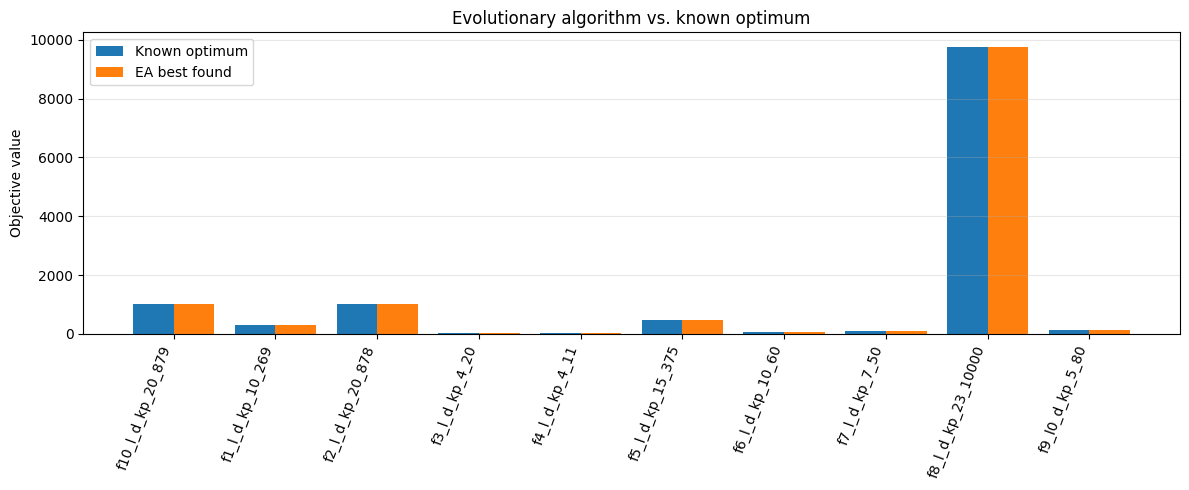

In [9]:
plot_df = summary_df.sort_values("instance")
x = np.arange(len(plot_df))

plt.figure(figsize=(12, 5))
plt.bar(x - 0.2, plot_df["known_optimum"], width=0.4, label="Known optimum")
plt.bar(x + 0.2, plot_df["best_found"], width=0.4, label="EA best found")
plt.xticks(x, plot_df["instance"], rotation=70, ha="right")
plt.ylabel("Objective value")
plt.title("Evolutionary algorithm vs. known optimum")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


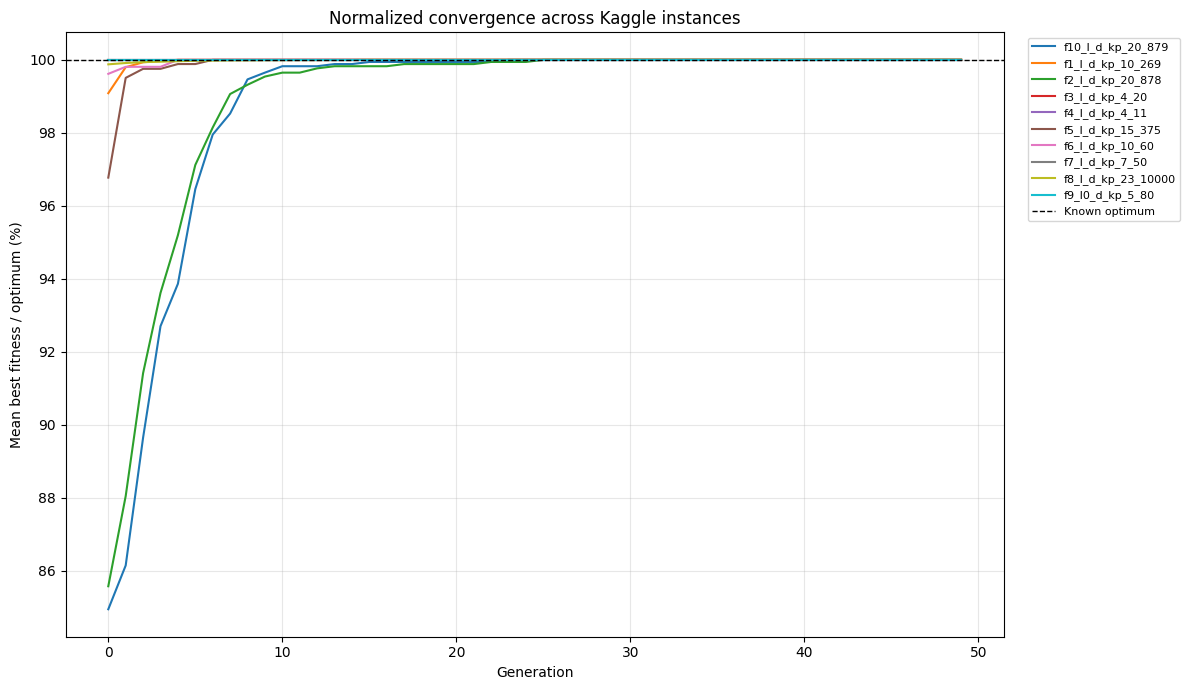

In [10]:
plt.figure(figsize=(12, 7))
for instance_name, runs in histories.items():
    curves = [r["best_history"] for r in runs]
    min_len = min(map(len, curves))
    mean_curve = np.mean([curve[:min_len] for curve in curves], axis=0)
    optimum = instances[instance_name][3]
    # Normalize so differently scaled objective values can share one plot.
    plt.plot(100 * mean_curve / optimum, label=instance_name)

plt.axhline(100, color="black", linestyle="--", linewidth=1, label="Known optimum")
plt.xlabel("Generation")
plt.ylabel("Mean best fitness / optimum (%)")
plt.title("Normalized convergence across Kaggle instances")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


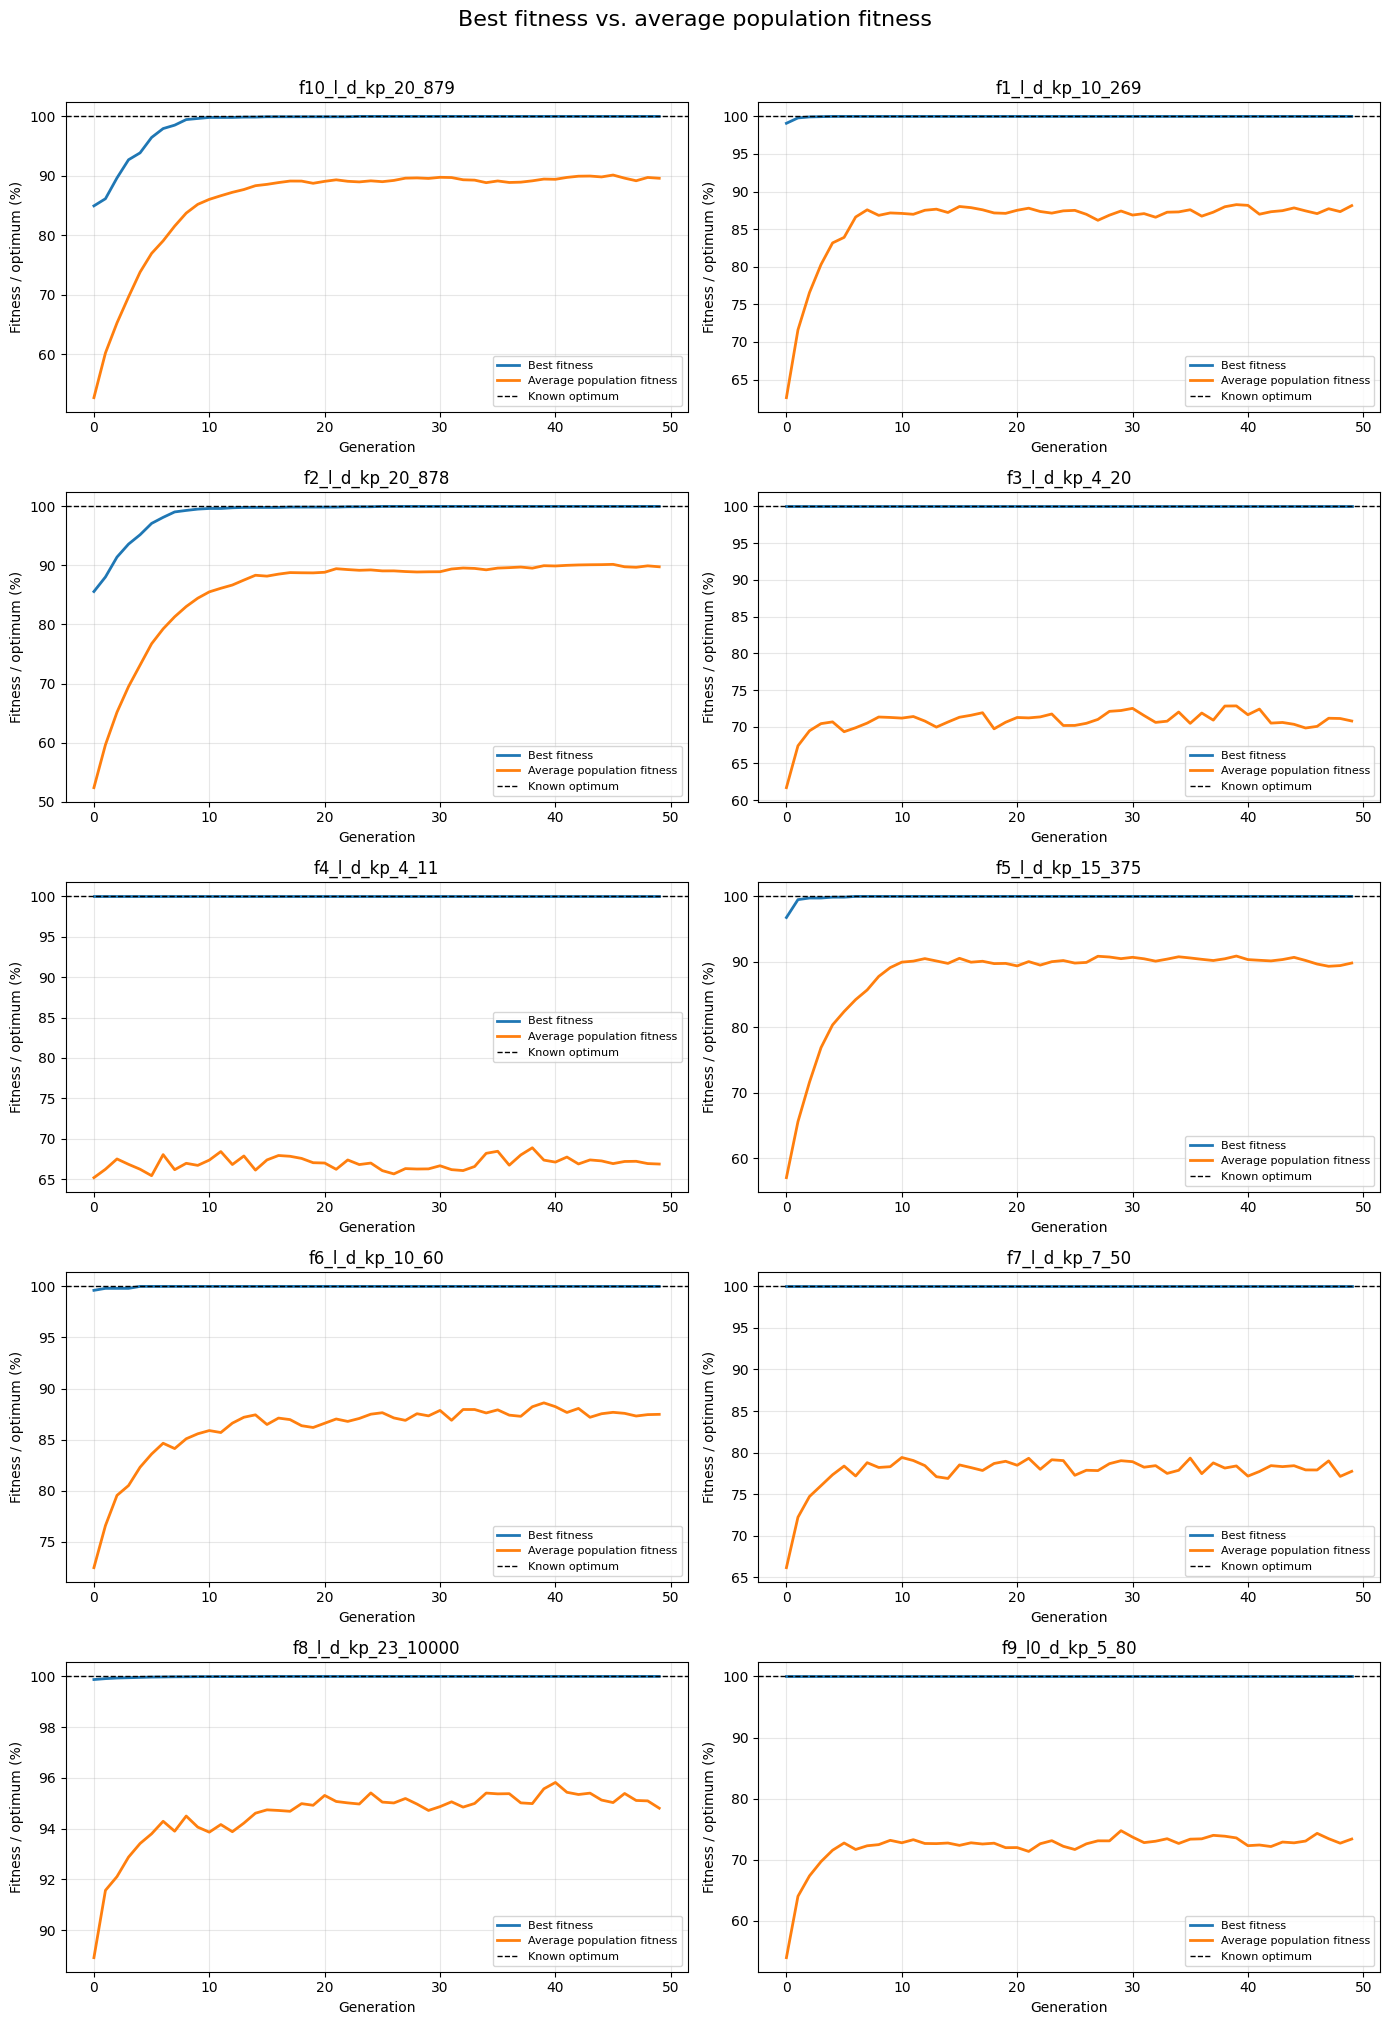

In [11]:
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.ravel()

for ax, (instance_name, runs) in zip(axes, histories.items()):
    best_curves = [run["best_history"] for run in runs]
    avg_curves = [run["avg_history"] for run in runs]
    min_len = min(
        min(map(len, best_curves)),
        min(map(len, avg_curves)),
    )

    mean_best = np.mean([curve[:min_len] for curve in best_curves], axis=0)
    mean_population = np.mean([curve[:min_len] for curve in avg_curves], axis=0)
    optimum = instances[instance_name][3]
    generations = np.arange(min_len)

    # Normalize by the known optimum so every instance uses the same scale.
    ax.plot(
        generations,
        100 * mean_best / optimum,
        label="Best fitness",
        linewidth=2,
    )
    ax.plot(
        generations,
        100 * mean_population / optimum,
        label="Average population fitness",
        linewidth=2,
    )
    ax.axhline(
        100,
        color="black",
        linestyle="--",
        linewidth=1,
        label="Known optimum",
    )
    ax.set_title(instance_name)
    ax.set_xlabel("Generation")
    ax.set_ylabel("Fitness / optimum (%)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle(
    "Best fitness vs. average population fitness",
    fontsize=16,
    y=1.01,
)
plt.tight_layout()
plt.show()


## 10. Interpretation

The most useful indicators are:

- **Best found:** whether the EA can reach the published optimum at least once.
- **Hit rate:** how reliably it reaches that optimum over repeated runs.
- **Average relative gap:** how far a typical run remains from the optimum.
- **Normalized convergence:** how quickly each instance approaches 100%.
- **Average population fitness:** how the overall population improves, not only its best individual.

